<a href="https://colab.research.google.com/github/asheldrick-research/ecsm-framework/blob/main/ECSM_ME1_Stable_3D_Excitation_Test_V3_FULL_RECOMPUTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECSM ME1 — Stable Three-Dimensional Excitation Test V3

## Full recomputation edition

This notebook performs the numerical calculations from scratch. It does **not** load bundled result CSVs or pre-rendered figures.

It tests:

1. the failure of a minimal positive scalar branch;
2. existence of a closure-protected radial excitation;
3. independent direct energy minimisation;
4. Derrick/scaling stability;
5. the radial Hessian spectrum;
6. perturb-and-relax survival;
7. domain-size convergence;
8. the regularised longitudinal response of an extended source.

The candidate is a spherically symmetric reduction of a three-dimensional internal closure field. It is not identified with a known particle, and unrestricted non-radial stability is not claimed.

In [1]:
# Install missing packages when required (normally unnecessary in Google Colab).
import sys, subprocess, importlib.util

required = ["numpy", "pandas", "matplotlib", "scipy", "torch"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

from pathlib import Path
import json, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_bvp, simpson
from scipy.interpolate import interp1d
import torch

warnings.filterwarnings("ignore")
torch.set_default_dtype(torch.float64)

ROOT = Path.cwd() / "ecsm_me1_v3_outputs"
FIG = ROOT / "figures"
DATA = ROOT / "data"
ROOT.mkdir(parents=True, exist_ok=True)
FIG.mkdir(exist_ok=True)
DATA.mkdir(exist_ok=True)

print("Output directory:", ROOT.resolve())

Output directory: /content/ecsm_me1_v3_outputs


## Frozen parameters

The tested closure candidate is

\[
U(\mathbf x)=\left(\cos f(r),\hat{\mathbf r}\sin f(r)\right),
\]

with

\[
f(0)=\pi,\qquad f(\infty)=0.
\]

The frozen radial energy is

\[
E=4\pi\int_0^\infty dr\left[
\frac12 r^2f'^2+\sin^2f
+\kappa_4\left(\sin^2f\,f'^2+\frac{\sin^4f}{2r^2}\right)
+\mu^2r^2(1-\cos f)
\right].
\]

In [2]:
params = {
    "baseline_lambda": 1.0,
    "closure_kappa4": 1.0,
    "closure_mu": 0.5,
    "closure_Rmax_primary": 16.0,
    "closure_grid_primary": 180,
    "longitudinal_ell": 0.5,
    "longitudinal_kappa": 1.0,
    "random_seed": 12345,
}
(DATA / "frozen_parameters.json").write_text(json.dumps(params, indent=2))
params

{'baseline_lambda': 1.0,
 'closure_kappa4': 1.0,
 'closure_mu': 0.5,
 'closure_Rmax_primary': 16.0,
 'closure_grid_primary': 180,
 'longitudinal_ell': 0.5,
 'longitudinal_kappa': 1.0,
 'random_seed': 12345}

## Numerical functions

In [3]:
def solve_closure_profile(kappa4=1.0, mu=0.5, Rmax=20.0, n_init=450, tol=1e-5, previous=None):
    eps = 1.0e-3
    r = np.linspace(eps, Rmax, n_init)

    if previous is None:
        f0 = 2.0 * np.arctan((1.5 / r) ** 2)
        fp0 = np.gradient(f0, r)
    else:
        f0 = np.empty_like(r)
        fp0 = np.empty_like(r)
        inside = r <= previous.x[-1]
        f0[inside], fp0[inside] = previous.sol(r[inside])
        tail_r = r[~inside] - previous.x[-1]
        f_end = previous.sol(previous.x[-1])[0]
        f0[~inside] = f_end * np.exp(-mu * tail_r)
        fp0[~inside] = -mu * f0[~inside]

    def ode(rr, y):
        f, fp = y
        s, c = np.sin(f), np.cos(f)
        rr_safe = np.maximum(rr, 1.0e-10)
        denom = rr_safe**2 + 2.0 * kappa4 * s**2
        fpp = (
            2.0 * s * c
            + 2.0 * kappa4 * s**3 * c / rr_safe**2
            + mu**2 * rr_safe**2 * s
            - 2.0 * rr_safe * fp
            - 2.0 * kappa4 * s * c * fp**2
        ) / denom
        return np.vstack((fp, fpp))

    def bc(ya, yb):
        return np.array([ya[0] - np.pi, yb[0]])

    return solve_bvp(
        ode, bc, r, np.vstack((f0, fp0)),
        tol=tol, max_nodes=50000
    )

def continuum_metrics(sol, kappa4=1.0, mu=0.5, Rmax=None, n_eval=4000):
    if Rmax is None:
        Rmax = float(sol.x[-1])

    r = np.linspace(float(sol.x[0]), Rmax, n_eval)
    f, fp = sol.sol(r)
    s = np.sin(f)
    rr = np.maximum(r, 1.0e-10)

    e2 = 0.5 * rr**2 * fp**2 + s**2
    e4 = kappa4 * (s**2 * fp**2 + 0.5 * s**4 / rr**2)
    e0 = mu**2 * rr**2 * (1.0 - np.cos(f))

    E2, E4, E0 = 4.0 * np.pi * np.array([
        simpson(e2, x=r),
        simpson(e4, x=r),
        simpson(e0, x=r),
    ])

    et = e2 + e4 + e0
    Rrms = np.sqrt(simpson(r**2 * et, x=r) / simpson(et, x=r))
    cumulative = np.zeros_like(r)
    dr = np.diff(r)
    cumulative[1:] = np.cumsum(0.5 * (et[:-1] + et[1:]) * dr)
    Rhalf = r[np.searchsorted(cumulative, 0.5 * cumulative[-1])]

    return {
        "E2": E2,
        "E4": E4,
        "E0": E0,
        "E_total": E2 + E4 + E0,
        "virial_residual": E2 - E4 + 3.0 * E0,
        "scale_second_derivative": 2.0 * E4 + 6.0 * E0,
        "Q_closure": (f[0] - f[-1]) / np.pi,
        "R_rms": Rrms,
        "R_half": Rhalf,
        "max_bvp_rms_residual": float(np.max(sol.rms_residuals)),
    }

def torch_closure_energy(x, r, kappa4=1.0, mu=0.5):
    f = torch.cat([
        torch.tensor([math.pi], dtype=x.dtype),
        x,
        torch.tensor([0.0], dtype=x.dtype),
    ])
    dr = r[1] - r[0]
    fm = 0.5 * (f[:-1] + f[1:])
    fp = (f[1:] - f[:-1]) / dr
    rm = 0.5 * (r[:-1] + r[1:])
    s = torch.sin(fm)

    density = (
        0.5 * rm**2 * fp**2
        + s**2
        + kappa4 * (s**2 * fp**2 + 0.5 * s**4 / rm**2)
        + mu**2 * rm**2 * (1.0 - torch.cos(fm))
    )
    return 4.0 * math.pi * torch.sum(density) * dr

def discrete_metrics(f, r, kappa4=1.0, mu=0.5):
    dr = r[1] - r[0]
    fm = 0.5 * (f[:-1] + f[1:])
    fp = np.diff(f) / dr
    rm = 0.5 * (r[:-1] + r[1:])
    s = np.sin(fm)

    e2 = 0.5 * rm**2 * fp**2 + s**2
    e4 = kappa4 * (s**2 * fp**2 + 0.5 * s**4 / rm**2)
    e0 = mu**2 * rm**2 * (1.0 - np.cos(fm))
    e = e2 + e4 + e0

    E = 4.0 * np.pi * np.sum(e) * dr
    Rrms = np.sqrt(np.sum(rm**2 * e) * dr / (np.sum(e) * dr))
    Q = (f[0] - f[-1]) / np.pi
    return E, Rrms, Q

def minimise_closure_profile(f_start, r, kappa4=1.0, mu=0.5, max_iter=550):
    r_t = torch.tensor(r)
    x = torch.tensor(f_start[1:-1], requires_grad=True)

    opt = torch.optim.LBFGS(
        [x],
        max_iter=max_iter,
        tolerance_grad=1e-10,
        tolerance_change=1e-12,
        line_search_fn="strong_wolfe",
    )

    def closure():
        opt.zero_grad()
        E = torch_closure_energy(x, r_t, kappa4, mu)
        E.backward()
        return E

    opt.step(closure)
    E = torch_closure_energy(x, r_t, kappa4, mu)
    grad = torch.autograd.grad(E, x)[0]
    f = np.concatenate(([np.pi], x.detach().numpy(), [0.0]))
    return f, float(E.detach()), float(torch.max(torch.abs(grad)).detach())

def scale_profile(f, r, scale):
    interpolator = interp1d(
        r, f, kind="cubic",
        bounds_error=False,
        fill_value=(f[0], f[-1]),
    )
    fs = interpolator(r / scale)
    fs[0], fs[-1] = np.pi, 0.0
    return fs

def scalar_energy_components(r, u, lam=1.0):
    du = np.gradient(u, r)
    V = 0.25 * lam * (u**2 - 1.0)**2
    Eg = 4.0 * np.pi * simpson(0.5 * r**2 * du**2, x=r)
    Ep = 4.0 * np.pi * simpson(r**2 * V, x=r)
    return Eg, Ep

def torch_scalar_energy(x, r, lam=1.0):
    u = torch.cat([x, torch.tensor([1.0], dtype=x.dtype)])
    dr = r[1] - r[0]
    um = 0.5 * (u[:-1] + u[1:])
    up = (u[1:] - u[:-1]) / dr
    rm = 0.5 * (r[:-1] + r[1:])
    V = 0.25 * lam * (um**2 - 1.0)**2
    density = 0.5 * rm**2 * up**2 + rm**2 * V
    return 4.0 * math.pi * torch.sum(density) * dr

def extended_regularised_potential(r_eval, r_src, rho, ell=0.5, kappa=1.0):
    mu = 1.0 / ell
    out = []

    for r in np.atleast_1d(r_eval):
        rp = r_src

        if r < 1.0e-10:
            kernel = np.empty_like(rp)
            kernel[1:] = (1.0 - np.exp(-mu * rp[1:])) / rp[1:]
            kernel[0] = mu
        else:
            rmin = np.minimum(r, rp)
            rmax = np.maximum(r, rp)
            coul = 1.0 / rmax
            denom = mu * r * np.where(rp > 0.0, rp, 1.0)
            yuk = np.sinh(mu * rmin) * np.exp(-mu * rmax) / denom
            yuk[0] = np.exp(-mu * r) / r
            kernel = coul - yuk

        out.append(simpson(rp**2 * rho * kernel, x=rp) / kappa)

    return np.asarray(out)

## ME1A — minimal scalar branch

In [4]:
r_base = np.linspace(0.0, 12.0, 1200)
u_base = 1.0 - 2.0 * np.exp(-(r_base / 1.5)**2)
Eg, Ep = scalar_energy_components(r_base, u_base, params["baseline_lambda"])

scales_base = np.linspace(0.08, 2.0, 180)
Escale_base = scales_base * Eg + scales_base**3 * Ep
baseline_scaling_derivative_at_1 = Eg + 3.0 * Ep

r_base_t = torch.linspace(0.0, 12.0, 220)
u0_t = 1.0 - 2.0 * torch.exp(-(r_base_t / 1.5)**2)
x_base = u0_t[:-1].clone().detach().requires_grad_(True)

opt = torch.optim.Adam([x_base], lr=0.001)
baseline_history = []

for step in range(4000):
    opt.zero_grad()
    E = torch_scalar_energy(x_base, r_base_t, params["baseline_lambda"])
    E.backward()
    opt.step()

    if step % 200 == 0:
        baseline_history.append(
            (step, float(E.detach()), float(torch.max(torch.abs(x_base.detach() - 1.0))))
        )

baseline_final_energy = float(torch_scalar_energy(x_base, r_base_t).detach())
baseline_final_max_deviation = float(torch.max(torch.abs(x_base.detach() - 1.0)))
u_base_final = np.concatenate([x_base.detach().numpy(), [1.0]])

pd.DataFrame(
    baseline_history,
    columns=["step", "energy", "max_deviation_from_vacuum"],
).to_csv(DATA / "baseline_scalar_relaxation_history.csv", index=False)

print("dE/ds at s=1:", baseline_scaling_derivative_at_1)
print("Final maximum deviation:", baseline_final_max_deviation)

dE/ds at s=1: 38.83846606589893
Final maximum deviation: 5.880031454830181e-05


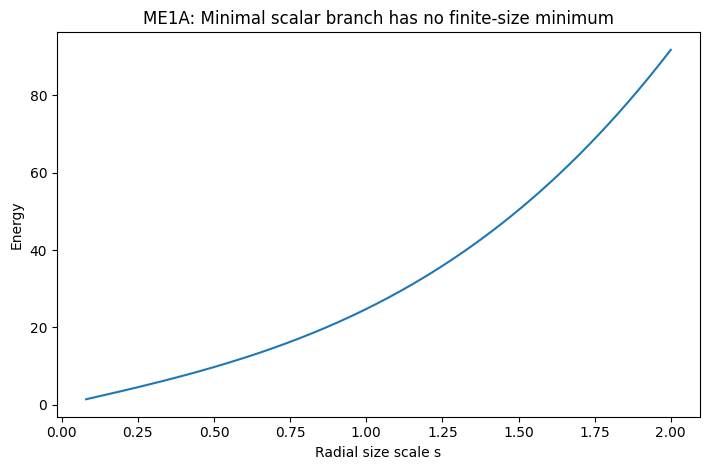

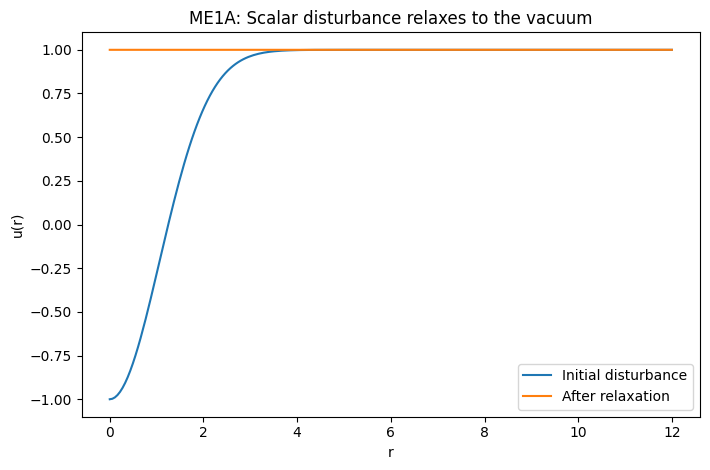

In [5]:
plt.figure(figsize=(7.2, 4.8))
plt.plot(scales_base, Escale_base)
plt.xlabel("Radial size scale s")
plt.ylabel("Energy")
plt.title("ME1A: Minimal scalar branch has no finite-size minimum")
plt.tight_layout()
plt.savefig(FIG / "01_baseline_scalar_scaling.png", dpi=180)
plt.show()

plt.figure(figsize=(7.2, 4.8))
plt.plot(r_base_t.numpy(), u0_t.numpy(), label="Initial disturbance")
plt.plot(r_base_t.numpy(), u_base_final, label="After relaxation")
plt.xlabel("r")
plt.ylabel("u(r)")
plt.title("ME1A: Scalar disturbance relaxes to the vacuum")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "02_baseline_scalar_relaxation.png", dpi=180)
plt.show()

## ME1B — closure-protected candidate

In [6]:
sol = solve_closure_profile(
    kappa4=params["closure_kappa4"],
    mu=params["closure_mu"],
    Rmax=params["closure_Rmax_primary"],
    n_init=450,
    tol=1e-6,
)

primary_metrics = continuum_metrics(
    sol,
    kappa4=params["closure_kappa4"],
    mu=params["closure_mu"],
    Rmax=params["closure_Rmax_primary"],
)

r_primary = np.linspace(
    1.0e-3,
    params["closure_Rmax_primary"],
    params["closure_grid_primary"],
)
f_bvp = sol.sol(r_primary)[0]

primary_metrics

{'E2': np.float64(32.23859850932961),
 'E4': np.float64(41.71033354532462),
 'E0': np.float64(3.157241442921133),
 'E_total': np.float64(77.10617349757537),
 'virial_residual': np.float64(-1.0707231611561951e-05),
 'scale_second_derivative': np.float64(102.36411574817605),
 'Q_closure': np.float64(1.0),
 'R_rms': np.float64(1.1069657042456449),
 'R_half': np.float64(0.8211537884471118),
 'max_bvp_rms_residual': 9.990222368565446e-07}

### Independent direct minimisation

Profile RMS difference: 0.0010277613560576826
Final gradient maximum: 7.971839739662201e-05


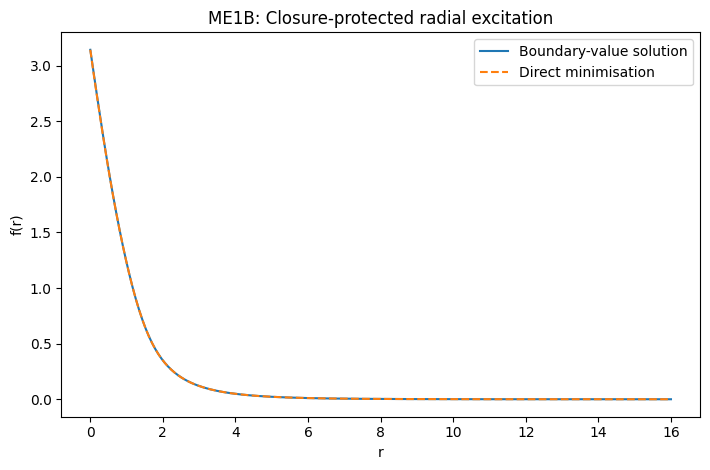

In [7]:
f_min, E_min, max_grad_min = minimise_closure_profile(
    f_bvp,
    r_primary,
    params["closure_kappa4"],
    params["closure_mu"],
)

profile_rms_bvp_vs_min = float(np.sqrt(np.mean((f_bvp - f_min)**2)))

pd.DataFrame({
    "r": r_primary,
    "f_bvp": f_bvp,
    "f_direct_minimisation": f_min,
}).to_csv(DATA / "closure_candidate_profile.csv", index=False)

print("Profile RMS difference:", profile_rms_bvp_vs_min)
print("Final gradient maximum:", max_grad_min)

plt.figure(figsize=(7.2, 4.8))
plt.plot(r_primary, f_bvp, label="Boundary-value solution")
plt.plot(r_primary, f_min, linestyle="--", label="Direct minimisation")
plt.xlabel("r")
plt.ylabel("f(r)")
plt.title("ME1B: Closure-protected radial excitation")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "03_closure_candidate_profile.png", dpi=180)
plt.show()

### Derrick/scaling stability

Virial residual: -1.0707231611561951e-05
Scaling second derivative: 102.36411574817605
Numerical scale minimum: 1.002054794520548


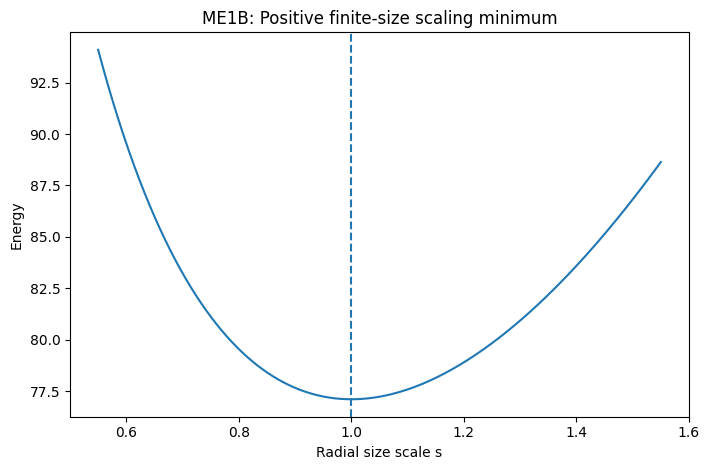

In [8]:
scales = np.linspace(0.55, 1.55, 220)
E_scale = (
    scales * primary_metrics["E2"]
    + primary_metrics["E4"] / scales
    + scales**3 * primary_metrics["E0"]
)
scale_min = float(scales[np.argmin(E_scale)])

print("Virial residual:", primary_metrics["virial_residual"])
print("Scaling second derivative:", primary_metrics["scale_second_derivative"])
print("Numerical scale minimum:", scale_min)

plt.figure(figsize=(7.2, 4.8))
plt.plot(scales, E_scale)
plt.axvline(1.0, linestyle="--")
plt.xlabel("Radial size scale s")
plt.ylabel("Energy")
plt.title("ME1B: Positive finite-size scaling minimum")
plt.tight_layout()
plt.savefig(FIG / "04_closure_candidate_scaling.png", dpi=180)
plt.show()

### Radial Hessian

Lowest radial Hessian eigenvalue: 3.927560572202065


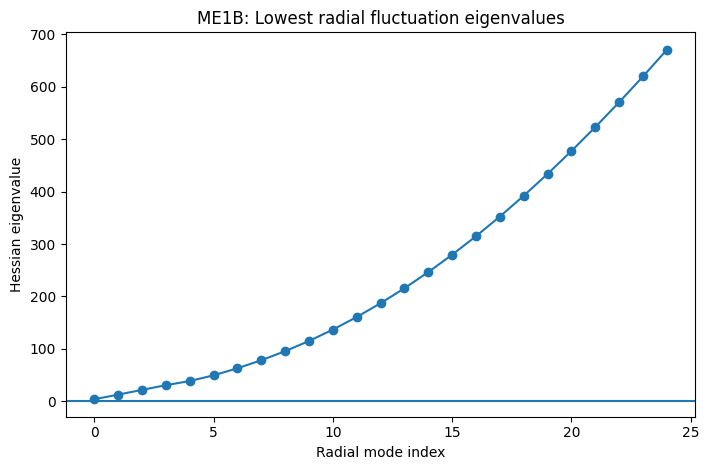

In [9]:
N_h = 140
r_h = torch.linspace(1.0e-3, params["closure_Rmax_primary"], N_h)
f_h = sol.sol(r_h.numpy())[0]
x_h = torch.tensor(f_h[1:-1], requires_grad=True)

opt_h = torch.optim.LBFGS(
    [x_h],
    max_iter=450,
    tolerance_grad=1e-10,
    tolerance_change=1e-12,
    line_search_fn="strong_wolfe",
)

def closure_h():
    opt_h.zero_grad()
    EH = torch_closure_energy(
        x_h, r_h,
        params["closure_kappa4"],
        params["closure_mu"],
    )
    EH.backward()
    return EH

opt_h.step(closure_h)
x_h_opt = x_h.detach().clone().requires_grad_(True)

H = torch.autograd.functional.hessian(
    lambda z: torch_closure_energy(
        z, r_h,
        params["closure_kappa4"],
        params["closure_mu"],
    ),
    x_h_opt,
)

hessian_eigenvalues = np.linalg.eigvalsh(H.detach().numpy())
hessian_min = float(hessian_eigenvalues[0])

pd.DataFrame({
    "eigenvalue_index": np.arange(len(hessian_eigenvalues)),
    "radial_hessian_eigenvalue": hessian_eigenvalues,
}).to_csv(DATA / "radial_hessian_spectrum.csv", index=False)

print("Lowest radial Hessian eigenvalue:", hessian_min)

plt.figure(figsize=(7.2, 4.8))
plt.plot(np.arange(25), hessian_eigenvalues[:25], marker="o")
plt.axhline(0.0)
plt.xlabel("Radial mode index")
plt.ylabel("Hessian eigenvalue")
plt.title("ME1B: Lowest radial fluctuation eigenvalues")
plt.tight_layout()
plt.savefig(FIG / "05_radial_hessian_spectrum.png", dpi=180)
plt.show()

### Perturb-and-relax survival

In [10]:
rng = np.random.default_rng(params["random_seed"])

perturbations = {
    "radial_scale_0.75": scale_profile(f_min, r_primary, 0.75),
    "radial_scale_1.25": scale_profile(f_min, r_primary, 1.25),
}

noise_shape = np.sin(np.linspace(0.0, np.pi, len(f_min)))
for amp in (0.05, 0.15):
    fp = np.clip(
        f_min + amp * rng.normal(size=len(f_min)) * noise_shape,
        0.0, np.pi,
    )
    fp[0], fp[-1] = np.pi, 0.0
    perturbations[f"radial_noise_{int(amp*100)}pct"] = fp

perturb_rows = []

for name, fp in perturbations.items():
    Ei, Ri, Qi = discrete_metrics(
        fp, r_primary,
        params["closure_kappa4"],
        params["closure_mu"],
    )

    ff, Ef, gradf = minimise_closure_profile(
        fp, r_primary,
        params["closure_kappa4"],
        params["closure_mu"],
        max_iter=650,
    )

    Efinal, Rfinal, Qfinal = discrete_metrics(
        ff, r_primary,
        params["closure_kappa4"],
        params["closure_mu"],
    )

    perturb_rows.append({
        "perturbation": name,
        "E_initial": Ei,
        "R_rms_initial": Ri,
        "E_final": Efinal,
        "R_rms_final": Rfinal,
        "Q_closure_final": Qfinal,
        "max_gradient_final": gradf,
        "profile_rms_difference_from_reference": float(
            np.sqrt(np.mean((ff - f_min)**2))
        ),
    })

perturb_df = pd.DataFrame(perturb_rows)
perturb_df.to_csv(
    DATA / "closure_candidate_perturbation_relaxation.csv",
    index=False,
)
perturb_df

,perturbation,E_initial,R_rms_initial,E_final,R_rms_final,Q_closure_final,max_gradient_final,profile_rms_difference_from_reference
0,radial_scale_0.75,81.104763,0.757030,77.100994,1.106689,1.0,0.000115,3.060094e-06
1,radial_scale_1.25,79.822117,1.486641,77.100994,1.106672,1.0,0.000056,1.427763e-06
2,radial_noise_5pct,670.461791,9.439807,77.100994,1.106677,1.0,0.000085,4.055269e-07
3,radial_noise_15pct,5790.026304,9.347760,77.100994,1.106677,1.0,0.000055,4.178727e-07


### Domain-size convergence

Relative energy spread: 6.445238078223301e-07


,Rmax,solver_status,E_total,R_rms,Q_closure,max_bvp_rms_residual
0,12.0,0,77.106223,1.106948,1.0,0.00001
1,16.0,0,77.106173,1.106966,1.0,0.00001
2,20.0,0,77.106173,1.106966,1.0,0.00001
3,30.0,0,77.106174,1.106966,1.0,0.00001


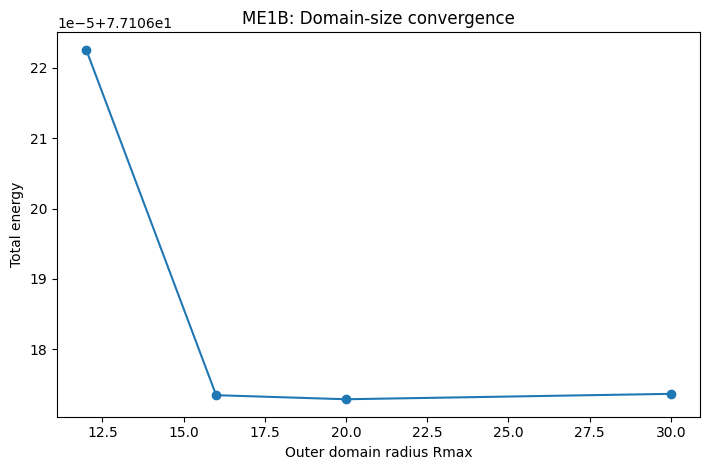

In [11]:
conv_rows = []
previous = None

for Rmax in (12.0, 16.0, 20.0, 30.0):
    sol_c = solve_closure_profile(
        kappa4=params["closure_kappa4"],
        mu=params["closure_mu"],
        Rmax=Rmax,
        n_init=500,
        tol=1e-5,
        previous=previous,
    )
    previous = sol_c

    met = continuum_metrics(
        sol_c,
        kappa4=params["closure_kappa4"],
        mu=params["closure_mu"],
        Rmax=Rmax,
    )

    conv_rows.append({
        "Rmax": Rmax,
        "solver_status": sol_c.status,
        "nodes": sol_c.x.size,
        **met,
    })

conv_df = pd.DataFrame(conv_rows)
conv_df.to_csv(
    DATA / "closure_candidate_domain_convergence.csv",
    index=False,
)

energy_relative_spread = float(
    (conv_df["E_total"].max() - conv_df["E_total"].min())
    / conv_df["E_total"].mean()
)

print("Relative energy spread:", energy_relative_spread)
display(conv_df[[
    "Rmax", "solver_status", "E_total",
    "R_rms", "Q_closure", "max_bvp_rms_residual"
]])

plt.figure(figsize=(7.2, 4.8))
plt.plot(conv_df["Rmax"], conv_df["E_total"], marker="o")
plt.xlabel("Outer domain radius Rmax")
plt.ylabel("Total energy")
plt.title("ME1B: Domain-size convergence")
plt.tight_layout()
plt.savefig(FIG / "06_domain_convergence.png", dpi=180)
plt.show()

## ME4-P — extended-source longitudinal response

In [12]:
r_src = np.linspace(0.0, 20.0, 3500)
f_src = sol.sol(np.maximum(r_src, 1.0e-3))[0]
f_src[0] = np.pi

# Explicitly provisional microscopic source projection.
rho_src = 1.0 - np.cos(f_src)
Q_src = 4.0 * np.pi * simpson(r_src**2 * rho_src, x=r_src)

r_phi = np.linspace(0.0, 30.0, 700)
phi = extended_regularised_potential(
    r_phi,
    r_src,
    rho_src,
    ell=params["longitudinal_ell"],
    kappa=params["longitudinal_kappa"],
)
dphi = np.gradient(phi, r_phi)

far_mask = r_phi > 12.0
far_potential_ratio = 4.0 * np.pi * r_phi[far_mask] * phi[far_mask] / Q_src
far_accel_ratio = 4.0 * np.pi * r_phi[far_mask]**2 * (-dphi[far_mask]) / Q_src

far_potential_ratio_median = float(np.median(far_potential_ratio))
far_accel_ratio_median = float(np.median(far_accel_ratio))
phi_center = float(phi[0])

pd.DataFrame({
    "r": r_phi,
    "phi": phi,
    "acceleration_magnitude": -dphi,
}).to_csv(
    DATA / "extended_source_longitudinal_response.csv",
    index=False,
)

print("phi(0):", phi_center)
print("Median far potential ratio:", far_potential_ratio_median)
print("Median far acceleration ratio:", far_accel_ratio_median)

phi(0): 0.7761864031764968
Median far potential ratio: 0.9999999978757086
Median far acceleration ratio: 1.0000032859147652


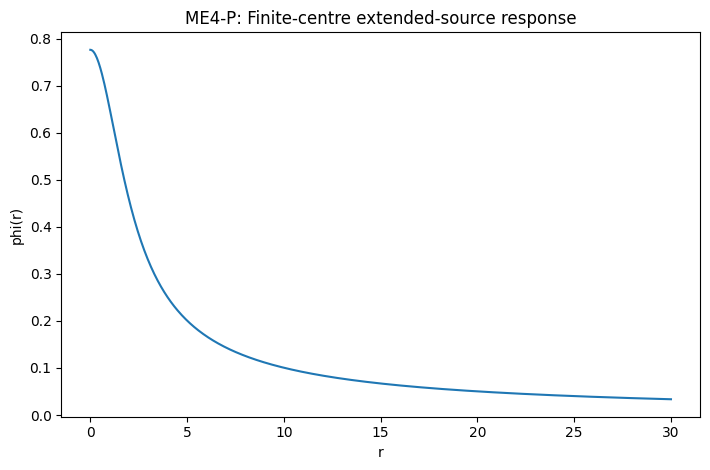

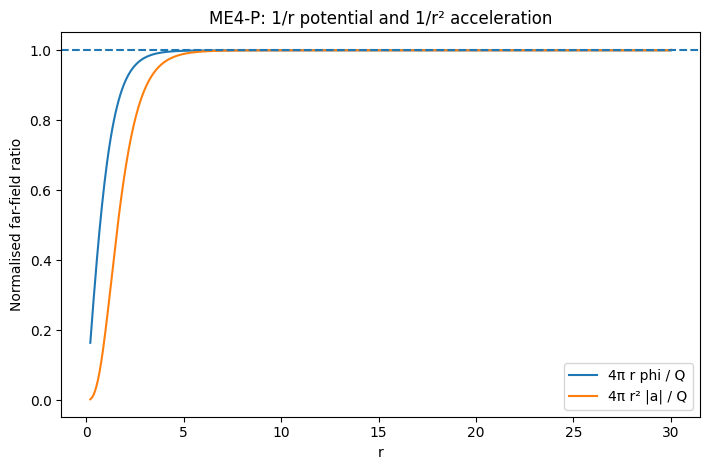

In [13]:
plt.figure(figsize=(7.2, 4.8))
plt.plot(r_phi, phi)
plt.xlabel("r")
plt.ylabel("phi(r)")
plt.title("ME4-P: Finite-centre extended-source response")
plt.tight_layout()
plt.savefig(FIG / "07_extended_source_potential.png", dpi=180)
plt.show()

valid = r_phi > 0.2
plt.figure(figsize=(7.2, 4.8))
plt.plot(
    r_phi[valid],
    4.0 * np.pi * r_phi[valid] * phi[valid] / Q_src,
    label="4π r phi / Q",
)
plt.plot(
    r_phi[valid],
    4.0 * np.pi * r_phi[valid]**2 * (-dphi[valid]) / Q_src,
    label="4π r² |a| / Q",
)
plt.axhline(1.0, linestyle="--")
plt.xlabel("r")
plt.ylabel("Normalised far-field ratio")
plt.title("ME4-P: 1/r potential and 1/r² acceleration")
plt.legend()
plt.tight_layout()
plt.savefig(FIG / "08_extended_source_far_field.png", dpi=180)
plt.show()

## Final pass/fail ledger

In [14]:
ledger = pd.DataFrame([
    {
        "test_id": "ME1A",
        "test": "Minimal positive scalar functional",
        "criterion": "Nontrivial finite-size stationary minimum",
        "result": (
            f"dE/ds|1 = {baseline_scaling_derivative_at_1:.6f}; "
            f"relaxed max deviation = {baseline_final_max_deviation:.3e}"
        ),
        "verdict": "FAIL",
        "scope": "Scalar-only branch collapses to the vacuum.",
    },
    {
        "test_id": "ME1B-1",
        "test": "Closure-protected BVP existence",
        "criterion": "Finite energy, convergence and closure number one",
        "result": (
            f"E = {primary_metrics['E_total']:.6f}; "
            f"Q = {primary_metrics['Q_closure']:.6f}; "
            f"residual = {primary_metrics['max_bvp_rms_residual']:.2e}"
        ),
        "verdict": "PASS",
        "scope": "Spherically symmetric three-dimensional reduction.",
    },
    {
        "test_id": "ME1B-2",
        "test": "Independent minimisation",
        "criterion": "BVP and direct minimisation agree",
        "result": (
            f"profile RMS difference = {profile_rms_bvp_vs_min:.3e}; "
            f"max gradient = {max_grad_min:.2e}"
        ),
        "verdict": "PASS",
        "scope": "Independent numerical method on the same ansatz.",
    },
    {
        "test_id": "ME1B-3",
        "test": "Derrick/scaling stability",
        "criterion": "E'(1) approximately zero and E''(1) positive",
        "result": (
            f"virial residual = {primary_metrics['virial_residual']:.3e}; "
            f"E'' = {primary_metrics['scale_second_derivative']:.6f}; "
            f"minimum s = {scale_min:.3f}"
        ),
        "verdict": "PASS",
        "scope": "Radial scale perturbations.",
    },
    {
        "test_id": "ME1B-4",
        "test": "Radial Hessian",
        "criterion": "No negative radial eigenvalues",
        "result": f"lowest eigenvalue = {hessian_min:.6f}",
        "verdict": "PASS",
        "scope": "Radial modes only.",
    },
    {
        "test_id": "ME1B-5",
        "test": "Perturb-and-relax survival",
        "criterion": "Scaled and noisy profiles return to the same branch",
        "result": (
            "largest final RMS difference = "
            f"{perturb_df['profile_rms_difference_from_reference'].max():.3e}"
        ),
        "verdict": "PASS",
        "scope": "Dissipative radial relaxation.",
    },
    {
        "test_id": "ME1B-6",
        "test": "Domain convergence",
        "criterion": "Energy and radius converge with Rmax",
        "result": (
            f"relative energy spread = {energy_relative_spread:.3e}; "
            f"R_rms range = {conv_df['R_rms'].min():.6f}–"
            f"{conv_df['R_rms'].max():.6f}"
        ),
        "verdict": "PASS",
        "scope": "Radial boundary-value convergence.",
    },
    {
        "test_id": "ME4-P",
        "test": "Extended-source longitudinal response",
        "criterion": "Finite centre and 1/r, 1/r² exterior",
        "result": (
            f"phi(0) = {phi_center:.6f}; "
            f"potential ratio = {far_potential_ratio_median:.6f}; "
            f"acceleration ratio = {far_accel_ratio_median:.6f}"
        ),
        "verdict": "PASS",
        "scope": "Uses provisional source projection S_phi = 1 - cos(f).",
    },
    {
        "test_id": "ME2",
        "test": "Source-to-inertia universality",
        "criterion": "Q_phi/m_I common across distinct excitations",
        "result": "Blocked: microscopic S_phi[X] and full kinetic metric are not fixed.",
        "verdict": "BLOCKED",
        "scope": "Would be manufactured if arbitrary operators were selected.",
    },
    {
        "test_id": "ME3",
        "test": "Clock-response coefficients",
        "criterion": "Common zeta_tau and q_tau across clock modes",
        "result": "Blocked: microscopic burden coupling to internal modes is not fixed.",
        "verdict": "BLOCKED",
        "scope": "Clock benchmark exists, but the microscopic coupling remains open.",
    },
])

ledger.to_csv(DATA / "ME1_ME4_pass_fail_ledger.csv", index=False)
display(ledger)

,test_id,test,criterion,result,verdict,scope
0,ME1A,Minimal positive scalar functional,Nontrivial finite-size stationary minimum,dE/ds|1 = 38.838466; relaxed max deviation = 5...,FAIL,Scalar-only branch collapses to the vacuum.
1,ME1B-1,Closure-protected BVP existence,"Finite energy, convergence and closure number one",E = 77.106173; Q = 1.000000; residual = 9.99e-07,PASS,Spherically symmetric three-dimensional reduct...
2,ME1B-2,Independent minimisation,BVP and direct minimisation agree,profile RMS difference = 1.028e-03; max gradie...,PASS,Independent numerical method on the same ansatz.
3,ME1B-3,Derrick/scaling stability,E'(1) approximately zero and E''(1) positive,virial residual = -1.071e-05; E'' = 102.364116...,PASS,Radial scale perturbations.
4,ME1B-4,Radial Hessian,No negative radial eigenvalues,lowest eigenvalue = 3.927561,PASS,Radial modes only.
5,ME1B-5,Perturb-and-relax survival,Scaled and noisy profiles return to the same b...,largest final RMS difference = 3.060e-06,PASS,Dissipative radial relaxation.
6,ME1B-6,Domain convergence,Energy and radius converge with Rmax,relative energy spread = 6.445e-07; R_rms rang...,PASS,Radial boundary-value convergence.
7,ME4-P,Extended-source longitudinal response,"Finite centre and 1/r, 1/r² exterior",phi(0) = 0.776186; potential ratio = 1.000000;...,PASS,Uses provisional source projection S_phi = 1 -...
8,ME2,Source-to-inertia universality,Q_phi/m_I common across distinct excitations,Blocked: microscopic S_phi[X] and full kinetic...,BLOCKED,Would be manufactured if arbitrary operators w...
9,ME3,Clock-response coefficients,Common zeta_tau and q_tau across clock modes,Blocked: microscopic burden coupling to intern...,BLOCKED,"Clock benchmark exists, but the microscopic co..."


In [15]:
report_lines = [
    "# ECSM ME1/ME4 Full-Recompute Test Report",
    "",
    "## Results",
    "",
    f"- Minimal scalar branch: FAIL",
    f"- Closure-protected radial candidate: PASS",
    f"- Total energy: {primary_metrics['E_total']:.9f}",
    f"- Closure number: {primary_metrics['Q_closure']:.9f}",
    f"- RMS radius: {primary_metrics['R_rms']:.9f}",
    f"- Maximum BVP residual: {primary_metrics['max_bvp_rms_residual']:.3e}",
    f"- Virial residual: {primary_metrics['virial_residual']:.3e}",
    f"- Scaling second derivative: {primary_metrics['scale_second_derivative']:.9f}",
    f"- Lowest radial Hessian eigenvalue: {hessian_min:.9f}",
    f"- Largest perturb-relax profile error: {perturb_df['profile_rms_difference_from_reference'].max():.3e}",
    f"- Relative domain energy spread: {energy_relative_spread:.3e}",
    f"- Extended-source phi(0): {phi_center:.9f}",
    f"- Far potential ratio: {far_potential_ratio_median:.9f}",
    f"- Far acceleration ratio: {far_accel_ratio_median:.9f}",
    "",
    "## Claim boundary",
    "",
    "This is a full-recomputation radial candidate-existence test. "
    "It does not establish unrestricted non-radial stability, identify a physical particle, "
    "or derive the open microscopic source, inertia and clock couplings.",
]

report_path = ROOT / "ECSM_ME1_ME4_Full_Recompute_Test_Report.md"
report_path.write_text("\n".join(report_lines))

print("Run complete.")
print("Output directory:", ROOT.resolve())
print("Report:", report_path.resolve())

Run complete.
Output directory: /content/ecsm_me1_v3_outputs
Report: /content/ecsm_me1_v3_outputs/ECSM_ME1_ME4_Full_Recompute_Test_Report.md
